# Energy conversion

 - <u>Lithium chemical potential energy conservation</u> 
    - Happens with the high energy state of lithium ions between anode and cathode ions
     - $\text{Lithium Chemical Potential Energy} = n F (\mu_{\text{Li,anode}} - \mu_{\text{Li,cathode}})$
     - <i> Real-World </i> The lithium battery doesn't randomy lose energy to the environment, but rather conserves it for a long time due to this chemical process.
  - <u>Lithium chemical potential energy to electrical</u>
    - Occurs via the discharge process
    - $\text{Electrical Energy Output} = n F (E_{\text{cathode}} - E_{\text{anode}})$
    - This is the process through which the system utilizes battery power.
 - <u>Electrical-to-thermal</u> 
    - AC curent from home 120V outlet => unit
    - Routed to a <u>nichrome wire or ceramic plate</u> (lower level <i>heating plate</i>)
    - Converts to thermal energy via Joule heating: $P = i^2r$
    - 85% effective in energy conversion
    - The wires typically go along the walls of the object, and the plate is typically at the bottom, resulting in even heating.
 - <u>Electrical-to-EM light</u>
    - This is done via a standard LED indicator, which glows red from electricity. Red indicators are typically used in this product.
 - <u>Thermal-to-mechanical</u>
    - Increase in heat => convecion of water leading to evaporation
    - The evaporated water exerts subtle mechanical pressure on the lid in an ideal system
    - Due to pores, the lid doesn't just *blast off* in real world scenarios
 - <u>Thermal-to-light</u> 
    - Rice cooker coil gleams red 
    - The coil gleaming red is due to blackbody radiation
    - Blackbody radiation is described by Planck's law: $B(\lambda, T) = \frac{2hc^2}{\lambda^5} \frac{1}{e^{\frac{hc}{\lambda k_B T}} - 1}$
    - Planck's law describes how much EM light is emitted from heat energy
 - <u>Thermal-to-chemical</u> 
   - The <i> Maillard reaction </i> occurs with heat input:
   - $ \text{Reducing Sugar} + \text{Amino Acid} \xrightarrow{\text{heat}} \text{Melanoidin (browning compounds)} + \text{other products} $
   - This is the process that results in the cooking that this object creates, resulting in edible output.


# Not energy conservation, but still important
 - <u>Phase Change Heat Storage (Thermal to thermal)</u>
   - Preserves thermal energy in high performance battery rice cookers
   - $Q = m \Delta H_{fus}$ or $Q = m \Delta H_{vap}$
   - $c\Delta T$ from hon.chemistry replaced with $\Delta H$ due to phase change
 - <u>Environmental Heat Loss (Thermal to environment)</u>
   - Escapes through walls via conduction (heat moves through solid material)
   - Escapes by pores in lid; no perfect sealing
   - Escapes via radiation (thermal energy becomes infrared waves) that travels through walls





### Planck's Law for Battery-Powered Rice Cookers

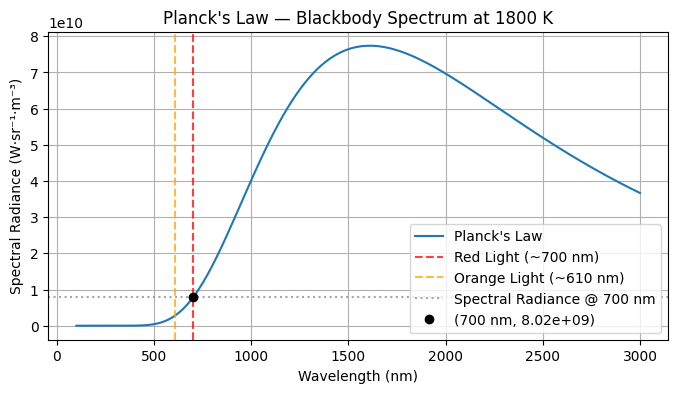

In [2]:
# Simulate and plot Planck's law using scipy and matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k

def plancks_law(wavelength, temperature):
    """
    wavelength: in meters (can be an array)
    temperature: in Kelvin
    Returns spectral radiance B (W·sr⁻¹·m⁻³)
    """
    numerator = 2 * h * c**2
    denominator = (wavelength**5) * (np.exp(h * c / (wavelength * k * temperature)) - 1)
    return numerator / denominator

# Simulate for visible wavelengths
wavelengths = np.linspace(1e-7, 3e-6, 400) # 100 nm (UV) to 3000 nm (IR)
T = 1800  # Temperature in Kelvin, typical for red-hot nichrome coil

B_lambda = plancks_law(wavelengths, T)

plt.figure(figsize=(8,4))
plt.plot(wavelengths * 1e9, B_lambda, label="Planck's Law")

# --- Highlight red/orange light wavelengths (about 610-700 nm for red, 590-610 nm for orange)
for color, nm, name in [("red", 700, "Red Light (~700 nm)"), ("orange", 610, "Orange Light (~610 nm)")]:
    plt.axvline(x=nm, color=color, linestyle='--', alpha=0.75, label=name)

# Add a perpendicular (horizontal) line showing the spectral radiance at 700 nm (typical for battery-powered rice cooker glow)
lambda_rice = 700 # nm
idx = np.abs(wavelengths * 1e9 - lambda_rice).argmin()
plt.axhline(y=B_lambda[idx], color="gray", linestyle=":", alpha=0.7, label=f"Spectral Radiance @ {lambda_rice} nm")

# Optional: Mark the intersection point
plt.plot(lambda_rice, B_lambda[idx], 'o', color='black', label=f"({lambda_rice} nm, {B_lambda[idx]:.2e})")

plt.title(f"Planck's Law — Blackbody Spectrum at {T} K")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Radiance (W·sr⁻¹·m⁻³)")
plt.grid(True)
plt.legend()
plt.show()

### Thermal-to-Chemical

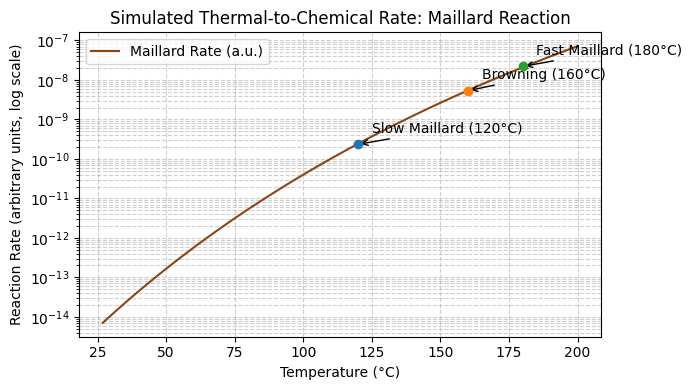

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate thermal-to-chemical conversion for the Maillard reaction

# The Maillard reaction rate is temperature dependent; 
# model using Arrhenius equation: rate = A * exp(-Ea / (R*T))
# These constants can be rough: 
A = 1e5  # pre-exponential factor, arbitrary units
Ea = 110e3  # activation energy, J/mol (rough value typical for Maillard)
R = 8.314  # gas constant, J/(mol·K)

temps = np.linspace(300, 200 + 273.15, 100)  # from 27°C to 200°C, in K

# Calculate rate
rate = A * np.exp(-Ea / (R * temps))

plt.figure(figsize=(7,4))
plt.semilogy(temps - 273.15, rate, color='saddlebrown', label="Maillard Rate (a.u.)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Reaction Rate (arbitrary units, log scale)")
plt.title("Simulated Thermal-to-Chemical Rate: Maillard Reaction")
plt.grid(True, which='both', linestyle='--', alpha=0.6)

# Mark typical cooking temperatures
for t,label in [(120, "Slow Maillard (120°C)"), (160, "Browning (160°C)"), (180, "Fast Maillard (180°C)")]:
    idx = np.abs((temps - 273.15) - t).argmin()
    plt.scatter([t], [rate[idx]], zorder=5)
    plt.annotate(label, xy=(t, rate[idx]), xytext=(t+5, rate[idx]*2),
                 arrowprops=dict(arrowstyle='->', lw=1), fontsize=10)

plt.tight_layout()
plt.legend()
plt.show()



### 🔬 Arrhenius Equatioin

$$
k = A e^{-E_a / (R T)}
$$

- $k$: reaction rate constant (how fast browning happens)
- $A$: frequency factor (depends on molecules colliding)
- $E_a$: activation energy (J/mol)
- $R$: gas constant ($8.314 \ \mathrm{J/(mol\cdot K)}$)
- $T$: temperature in Kelvin

In cooking, you can pretend that “brownness” increases more quickly at higher $k$.


In [9]:
# Rice cooker simulation
import numpy             as np
import matplotlib.pyplot as plt
import math              as m

# Parameters
m_rice = 0.15       # kg, mass of dry rice
m_water = 0.25      # kg, mass of water

# Chemical potential energy to electrical
n = 1               # 1 mol of lithium ions transferred
F = 96485           # C/mol, Faraday's constant
E_cathode = -3.04   # V, cathode potential
E_anode = -2.71     # V, anode potential
Q = n * F * (E_cathode - E_anode)

print(f"Electrical energy: {abs(Q):.2f} J")

# Electrical to thermal
effectiveness = 0.80
Thermal = Q*effectiveness

print(f"Thermal energy: {Thermal:.2f} J")

# Arrhenius Equation Rice Cooker (Component of Malliard Reaction)
A = 1e5  # pre-exponential factor, arbitrary units
Ea = 110e3  # activation energy, J/mol (rough value typical for Maillard)
R = 8.314  # gas constant, J/(mol·K)
T = 100 + 273.15  # temperature in Kelvin
k = A * np.exp(-Ea / (R * T))

print(f"Reaction rate: {k:.2e}")

# Arrhenius and Thermal J
t = 120 # seconds
thermal_energy = Thermal * t
print(f"Thermal energy: {thermal_energy:.2f} J after {t:.2f} seconds")

# Everyone views the world through their own perspective. 
# My perspective is based on programming, hence why I represented this concept as such.


Electrical energy: 31840.05 J
Thermal energy: -25472.04 J
Reaction rate: 3.99e-11
Thermal energy: -3056644.80 J after $120.00 seconds


In [12]:
import numpy             as np
import matplotlib.pyplot as plt
import math              as m
import json

# All preset variables in a dictionary
presets = {
    "m_rice": 0.15,          # kg, mass of dry rice
    "m_water": 0.25,         # kg, mass of water
    "n": 1,                  # mol of lithium ions transferred
    "F": 96485,              # C/mol, Faraday's constant
    "E_cathode": -3.04,      # V, cathode potential
    "E_anode": -2.71,        # V, anode potential
    "effectiveness": 0.80,   # electrical to thermal
    "A": 1e5,                # pre-exponential factor, arbitrary units
    "Ea": 110e3,             # activation energy, J/mol
    "R": 8.314,              # gas constant, J/(mol·K)
    "T_C": 100,              # temperature in Celsius
    "t": 120                 # seconds
}

with open("rice-spec.json", "w") as f:
    json.dump(presets, f, indent=4)

def load(json_preset):
    '''
    Loads a preset rice cooker schema
    '''
    global presets
    with open(json_preset, "r") as f:
        presets = json.load(f)

def derive(presets):
    '''
    Derives the variables from the preset rice cooker configuration
    '''
    global T, Q, k, thermal_energy, Thermal
    T = presets["T_C"] + 273.15
    Q = presets["n"] * presets["F"] * (presets["E_cathode"] - presets["E_anode"])
    Thermal = Q * presets["effectiveness"]
    k = presets["A"] * np.exp(-presets["Ea"] / (presets["R"] * T))
    thermal_energy = Thermal * presets["t"]

def dp():
    '''
    Prints the key derived values: Electrical energy, Thermal energy, Reaction rate, and
    cumulative Thermal energy after preset time.
    '''
    print(f"Electrical energy: {abs(Q):.2f} J")
    print(f"Thermal energy: {Thermal:.2f} J")
    print(f"Reaction rate: {k:.2e}")
    print(f"Thermal energy: {thermal_energy:.2f} J after {presets['t']:.2f} seconds")

# Attach as a .print method to derive
derive.print = dp

derive.print()

Electrical energy: 31840.05 J
Thermal energy: -25472.04 J
Reaction rate: 3.99e-11
Thermal energy: -3056644.80 J after 120.00 seconds
